In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/physionet-challenge-2016/training-a/a0032.wav
/kaggle/input/physionet-challenge-2016/training-a/a0343.hea
/kaggle/input/physionet-challenge-2016/training-a/a0031.dat
/kaggle/input/physionet-challenge-2016/training-a/a0142.wav
/kaggle/input/physionet-challenge-2016/training-a/a0393.hea
/kaggle/input/physionet-challenge-2016/training-a/a0321.dat
/kaggle/input/physionet-challenge-2016/training-a/a0360.hea
/kaggle/input/physionet-challenge-2016/training-a/a0254.hea
/kaggle/input/physionet-challenge-2016/training-a/a0211.wav
/kaggle/input/physionet-challenge-2016/training-a/a0409.wav
/kaggle/input/physionet-challenge-2016/training-a/a0314.wav
/kaggle/input/physionet-challenge-2016/training-a/a0241.wav
/kaggle/input/physionet-challenge-2016/training-a/a0189.dat
/kaggle/input/physionet-challenge-2016/training-a/a0026.dat
/kaggle/input/physionet-challenge-2016/training-a/a0376.hea
/kaggle/input/physionet-challenge-2016/training-a/a0322.wav
/kaggle/input/physionet-challenge-2016/t

In [2]:
import os
import numpy as np
import pandas as pd
import librosa
from sklearn.preprocessing import LabelEncoder


In [3]:
# Base directory for the dataset
base_path = '/kaggle/input/physionet-challenge-2016'

# Training folders
train_folders = ['training-a', 'training-b', 'training-c', 'training-d', 'training-e', 'training-f']

# Load reference files into one DataFrame
def load_all_labels(base_path, folders):
    dfs = []
    for folder in folders:
        ref_path = os.path.join(base_path, folder, 'REFERENCE.csv')
        if os.path.exists(ref_path):
            df = pd.read_csv(ref_path, header=None)
            df.columns = ['filename', 'label']
            df['filename'] = df['filename'].astype(str)
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

labels_df = load_all_labels(base_path, train_folders)


In [4]:
# Parameters
sample_rate = 22050
n_mfcc = 40
max_pad_len = 862  # Adjust based on your longest audio file (or max time frame you want)

# Function to extract MFCC from an audio file
def extract_features(file_path):
    try:
        audio, sr = librosa.load(file_path, sr=sample_rate)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Padding or truncating
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
            
        return mfcc.flatten()  # Flatten for classification
    except Exception as e:
        print("Error:", file_path, e)
        return None


In [5]:
features = []
targets = []

for folder in train_folders:
    folder_path = os.path.join(base_path, folder)
    ref_path = os.path.join(folder_path, 'REFERENCE.csv')
    
    if not os.path.exists(ref_path):
        continue
    
    ref_df = pd.read_csv(ref_path, header=None)
    ref_df.columns = ['filename', 'label']
    
    for i, row in ref_df.iterrows():
        file_name = row['filename']
        label = row['label']
        wav_path = os.path.join(folder_path, file_name + '.wav')
        
        if os.path.exists(wav_path):
            mfcc = extract_features(wav_path)
            if mfcc is not None:
                features.append(mfcc)
                targets.append(label)

# Convert to arrays
X = np.array(features)
y = np.array(targets)


In [6]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)


In [7]:
import os
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


In [8]:
file_path = "/kaggle/input/physionet-challenge-2016/training-a/a0007.wav"
y, sr = librosa.load(file_path, sr=None)  # Load original sampling rate


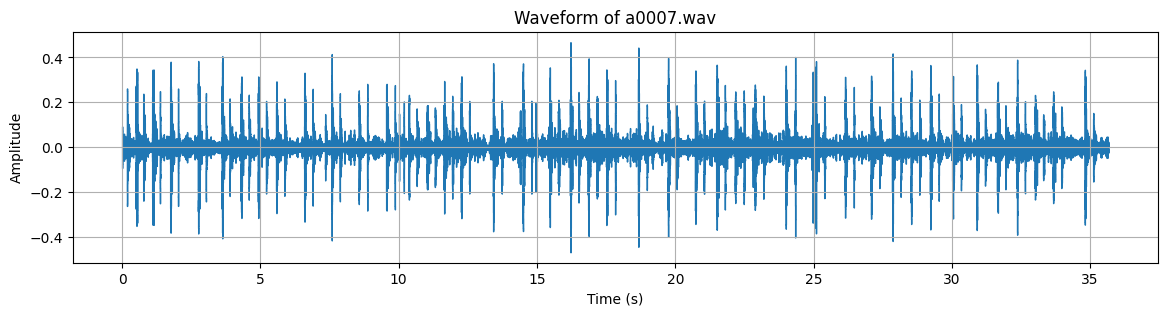

In [9]:
plt.figure(figsize=(14, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform of a0007.wav")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
plt.show()


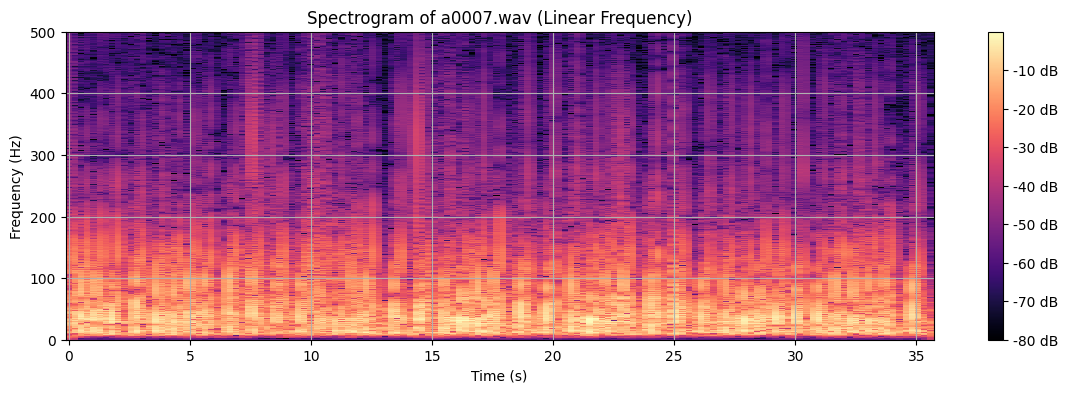

In [10]:
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

plt.figure(figsize=(14, 4))
librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='hz', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram of a0007.wav (Linear Frequency)")
plt.ylim(0, 500)  # Only show low frequencies up to 500Hz
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.grid()
plt.show()


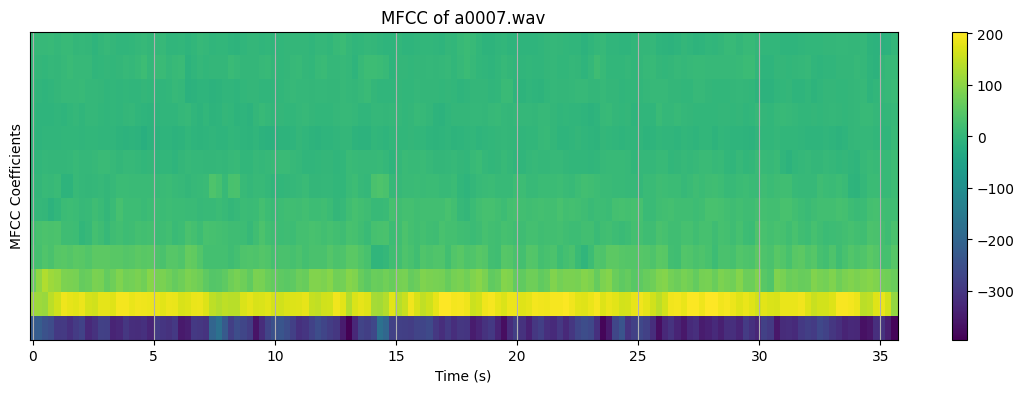

In [11]:
mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)

plt.figure(figsize=(14, 4))
librosa.display.specshow(mfccs, x_axis='time', sr=sr, cmap='viridis')
plt.colorbar()
plt.title("MFCC of a0007.wav")
plt.xlabel("Time (s)")
plt.ylabel("MFCC Coefficients")
plt.grid()
plt.show()


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


2025-07-16 18:16:16.910419: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752689777.110171      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752689777.168895      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1752689788.564662      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/d

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │     8,827,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,860,290 (33.80 MB)

 Trainable params: 8,860,290 (33.80 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(X_train, y_train,
                    epochs=30,
                    batch_size=32,
                    validation_split=0.2)


Epoch 1/30


I0000 00:00:1752689792.348775      71 service.cc:148] XLA service 0x7e9f1400a2e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1752689792.349443      71 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1752689792.560237      71 cuda_dnn.cc:529] Loaded cuDNN version 90300


39/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6621 - loss: 247.9943

I0000 00:00:1752689793.998688      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.6707 - loss: 214.3503 - val_accuracy: 0.7129 - val_loss: 9.5052
Epoch 2/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7376 - loss: 14.9939 - val_accuracy: 0.7803 - val_loss: 0.5064
Epoch 3/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7894 - loss: 0.6573 - val_accuracy: 0.7765 - val_loss: 0.4677
Epoch 4/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7995 - loss: 0.8698 - val_accuracy: 0.7803 - val_loss: 0.5298
Epoch 5/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8015 - loss: 0.5146 - val_accuracy: 0.7803 - val_loss: 0.5186
Epoch 6/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7970 - loss: 0.4979 - val_accuracy: 0.7803 - val_loss: 0.4638
Epoch 7/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7808 - loss: 0.4877 - val_accuracy: 0.7803 - val_loss: 0.5236
Epoch 8/30
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8054 - loss: 0.4920 - val_accuracy: 0.7803 - val_loss: 0.5236

In [15]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7937 - loss: 0.5088
Test Accuracy: 0.7948


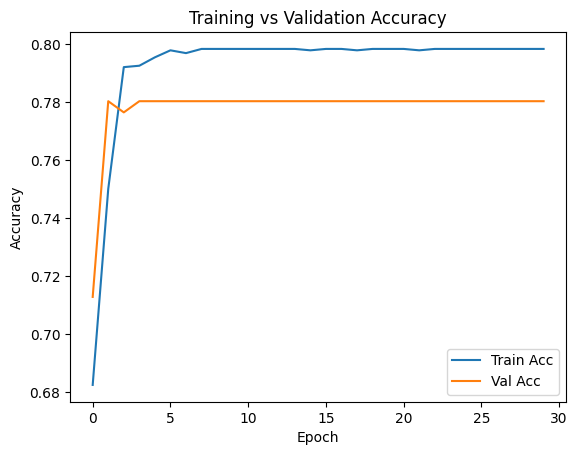

In [16]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()


**RNN**

# *Re-Extract MFCCs as Sequences (for GRU model)*

In [17]:
def extract_mfcc_sequence(file_path, n_mfcc=40, max_pad_len=862):
    try:
        audio, sr = librosa.load(file_path, sr=22050)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        
        # Pad or truncate to fixed length (time steps)
        if mfcc.shape[1] < max_pad_len:
            pad_width = max_pad_len - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_pad_len]
        
        return mfcc.T  # Shape: (timesteps, features)
    except Exception as e:
        print("Error processing", file_path, e)
        return None


# Extract All Features and Labels

In [18]:
X = []
y = []

for folder in train_folders:
    folder_path = os.path.join(base_path, folder)
    ref_path = os.path.join(folder_path, 'REFERENCE.csv')

    if not os.path.exists(ref_path):
        continue

    df = pd.read_csv(ref_path, header=None)
    df.columns = ['filename', 'label']

    for i, row in df.iterrows():
        file_id = row['filename']
        label = row['label']
        wav_path = os.path.join(folder_path, file_id + '.wav')

        if os.path.exists(wav_path):
            mfcc_seq = extract_mfcc_sequence(wav_path)
            if mfcc_seq is not None:
                X.append(mfcc_seq)
                y.append(label)

# Convert to NumPy arrays
X = np.array(X)  # Shape: (samples, time, features)
y = np.array(y)


# Encode Labels and Split Dataset

In [19]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)


In [20]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Masking

model = Sequential([
    Masking(mask_value=0.0, input_shape=(X_train.shape[1], X_train.shape[2])),
    GRU(128, return_sequences=False),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/masking.py:47: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 862, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        65,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,666 (287.76 KB)

 Trainable params: 73,666 (287.76 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=30,
                    batch_size=16)


Epoch 1/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.7617 - loss: 0.5594 - val_accuracy: 0.7861 - val_loss: 0.4278
Epoch 2/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8048 - loss: 0.4389 - val_accuracy: 0.8227 - val_loss: 0.4049
Epoch 3/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8237 - loss: 0.3860 - val_accuracy: 0.8382 - val_loss: 0.3674
Epoch 4/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.8430 - loss: 0.3671 - val_accuracy: 0.8073 - val_loss: 0.3742
Epoch 5/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8246 - loss: 0.3955 - val_accuracy: 0.8227 - val_loss: 0.3408
Epoch 6/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8237 - loss: 0.3691 - val_accuracy: 0.8536 - val_loss: 0.3403
Epoch 7/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8429 - loss: 0.3443 - val_accuracy: 0.8478 - val_loss: 0.3285
Epoch 8/30
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.8408 - loss: 0.3288 - val_accu

In [22]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8974 - loss: 0.2411
Test Accuracy: 0.8873


In [23]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import cv2


#  Convert MFCCs to 224x224 RGB Images

In [24]:
def mfcc_to_image(file_path, sr=22050, n_mfcc=40, image_size=(224, 224)):
    try:
        y, sr = librosa.load(file_path, sr=sr)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)

        # Convert to image
        fig = plt.figure(figsize=(2.24, 2.24), dpi=100)
        plt.axis('off')
        librosa.display.specshow(mfcc, x_axis=None, y_axis=None, cmap='viridis')
        fig.canvas.draw()

        # Convert to array
        image = np.frombuffer(fig.canvas.tostring_rgb(), dtype=np.uint8)
        image = image.reshape(fig.canvas.get_width_height()[::-1] + (3,))
        plt.close(fig)

        # Resize to ResNet50 input size
        image = cv2.resize(image, image_size)
        return preprocess_input(img_to_array(image))
    except Exception as e:
        print("Error:", file_path, e)
        return None


# Extract Images and Labels

In [25]:
X = []
y = []

for folder in train_folders:
    folder_path = os.path.join(base_path, folder)
    ref_path = os.path.join(folder_path, 'REFERENCE.csv')

    if not os.path.exists(ref_path):
        continue

    df = pd.read_csv(ref_path, header=None)
    df.columns = ['filename', 'label']

    for i, row in df.iterrows():
        file_id = row['filename']
        label = row['label']
        wav_path = os.path.join(folder_path, file_id + '.wav')

        if os.path.exists(wav_path):
            img = mfcc_to_image(wav_path)
            if img is not None:
                X.append(img)
                y.append(label)

X = np.array(X)
y = np.array(y)


In [26]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_cat = to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_cat, test_size=0.2, stratify=y_encoded, random_state=42)


# Build the ResNet50 Model

In [27]:
input_tensor = Input(shape=(224, 224, 3))
base_model = ResNet50(weights='imagenet', include_top=False, input_tensor=input_tensor)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
output = Dense(y_cat.shape[1], activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,242 (90.98 MB)

 Trainable params: 262,530 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor_15']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


130/130 ━━━━━━━━━━━━━━━━━━━━ 28s 114ms/step - accuracy: 0.7858 - loss: 0.5085 - val_accuracy: 0.8343 - val_loss: 0.3575
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.8347 - loss: 0.3795 - val_accuracy: 0.8208 - val_loss: 0.3725
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8403 - loss: 0.3430 - val_accuracy: 0.8921 - val_loss: 0.3045
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8506 - loss: 0.3234 - val_accuracy: 0.8767 - val_loss: 0.3011
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8310 - loss: 0.3505 - val_accuracy: 0.8208 - val_loss: 0.3768
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8623 - loss: 0.2987 - val_accuracy: 0.8786 - val_loss: 0.2831
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8856 - loss: 0.2724 - val_accuracy: 0.8613 - val_loss: 0.2941
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.8746 - loss: 0.2678 - val_accuracy: 0.8

In [29]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 6s 155ms/step - accuracy: 0.9203 - loss: 0.1978
Test Accuracy: 0.9043


In [30]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Freeze base layers (optional)
for layer in base_model.layers:
    layer.trainable = False

# Custom head
x = Conv2D(64, (3, 3), activation='relu')(base_model.output)
x = MaxPooling2D(pool_size=(2, 2))(x)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
output = Dense(2, activation='sigmoid')(x)  # <-- Binary

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='binary_crossentropy',                # <-- Binary loss
              metrics=['accuracy'])

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,853,221 (18.51 MB)

 Trainable params: 803,650 (3.07 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2,
                    verbose=1)


Epoch 1/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 54s 188ms/step - accuracy: 0.8075 - loss: 0.5029 - val_accuracy: 0.7977 - val_loss: 0.4575
Epoch 2/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.7877 - loss: 0.4629 - val_accuracy: 0.7919 - val_loss: 0.4374
Epoch 3/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8190 - loss: 0.4196 - val_accuracy: 0.7938 - val_loss: 0.4478
Epoch 4/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8179 - loss: 0.4231 - val_accuracy: 0.8247 - val_loss: 0.3907
Epoch 5/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8159 - loss: 0.4129 - val_accuracy: 0.8324 - val_loss: 0.3830
Epoch 6/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8339 - loss: 0.3809 - val_accuracy: 0.8247 - val_loss: 0.3894
Epoch 7/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8422 - loss: 0.3706 - val_accuracy: 0.8401 - val_loss: 0.3681
Epoch 8/50
130/130 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.8519 - loss: 0.3500 - val_ac

In [32]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")


21/21 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.8912 - loss: 0.2680
Test Accuracy: 0.8812
